# Radial Push-Pull Well Transport

This example demonstrates the radial push-pull well model for simulating tracer tests
in a vertically heterogeneous aquifer.

## Overview

A push-pull tracer test involves:
1. **Injection phase**: Pumping tracer-laden water into a well
2. **Rest phase** (optional): Waiting with no flow
3. **Extraction phase**: Pumping water back out and measuring tracer concentration

Transport follows **LIFO** (last-in-first-out) ordering: the most recently injected
water is extracted first. Without diffusion, recovery is perfect regardless of aquifer
heterogeneity. With diffusion, layers with smaller height push the tracer front further
radially, causing irreversible spreading and incomplete recovery.

See the [radial module API](https://gwtransport.github.io/gwtransport/api/modules.html#module-gwtransport.radial) for details.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gwtransport.radial import gamma_push_pull_well, push_pull_well
from gwtransport.utils import step_plot_coords

## Setup: Push-Pull Tracer Test

We simulate a tracer test with:
- **Injection**: Q = +100 m³/day, C = 1.0, for 10 days
- **Rest**: Q = 0, for 5 days
- **Extraction**: Q = -100 m³/day, for 20 days

In [2]:
n_inject, n_rest, n_extract = 10, 5, 20
n_total = n_inject + n_rest + n_extract

flow = np.zeros(n_total)
flow[:n_inject] = 100.0
flow[n_inject + n_rest :] = -100.0

cin = np.zeros(n_total)
cin[:n_inject] = 1.0

tedges = pd.date_range("2020-01-01", periods=n_total + 1, freq="D")

## Pure Advection: Perfect Recovery

Without diffusion, the LIFO stack gives perfect tracer recovery.
Layer heterogeneity is invisible — all distributions give the same result.

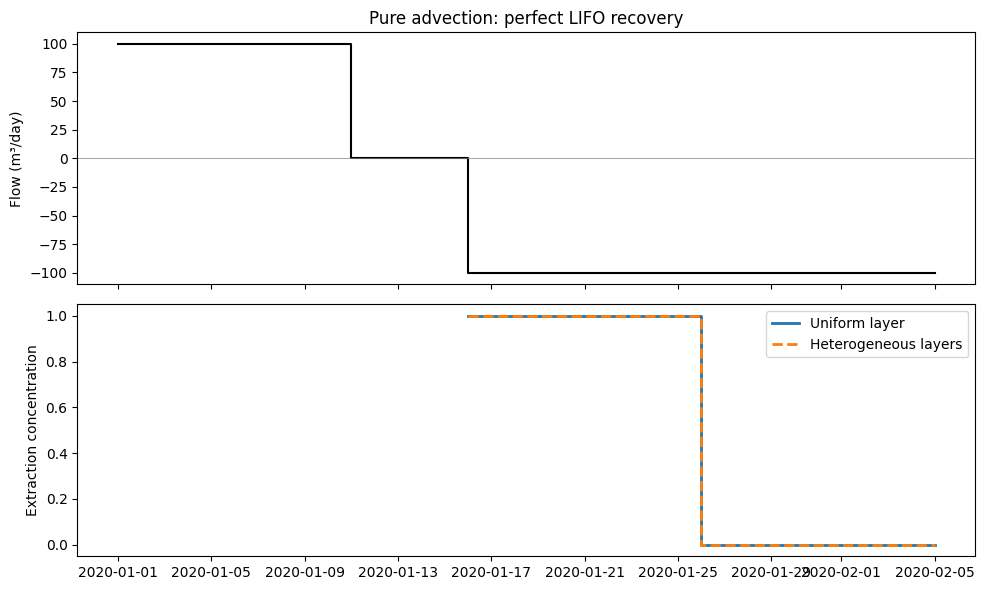

In [3]:
# Single uniform layer
cout_uniform = push_pull_well(
    flow=flow,
    cin=cin,
    tedges=tedges,
    cout_tedges=tedges,
    layer_heights=np.array([5.0]),
    porosity=0.3,
)

# Heterogeneous layers
cout_hetero = push_pull_well(
    flow=flow,
    cin=cin,
    tedges=tedges,
    cout_tedges=tedges,
    layer_heights=np.array([1.0, 3.0, 5.0, 10.0, 20.0]),
    porosity=0.3,
)

fig, (ax_flow, ax) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Flow subplot (positive = injection)
xf, yf = step_plot_coords(edges=tedges, values=flow)
ax_flow.plot(xf, yf, color="black", linewidth=1.5)
ax_flow.axhline(0, color="gray", linewidth=0.5)
ax_flow.set_ylabel("Flow (m³/day)")
ax_flow.set_title("Pure advection: perfect LIFO recovery")

# Concentration subplot
x, y = step_plot_coords(edges=tedges, values=cout_uniform)
ax.plot(x, y, label="Uniform layer", linewidth=2)
x, y = step_plot_coords(edges=tedges, values=cout_hetero)
ax.plot(x, y, label="Heterogeneous layers", linewidth=2, linestyle="--")
ax.set_ylabel("Extraction concentration")
ax.legend()
plt.tight_layout()
plt.show()

## Effect of Molecular Diffusion

With molecular diffusion, the sharp front gets smeared. Higher diffusivity causes
more spreading and less complete tracer recovery.

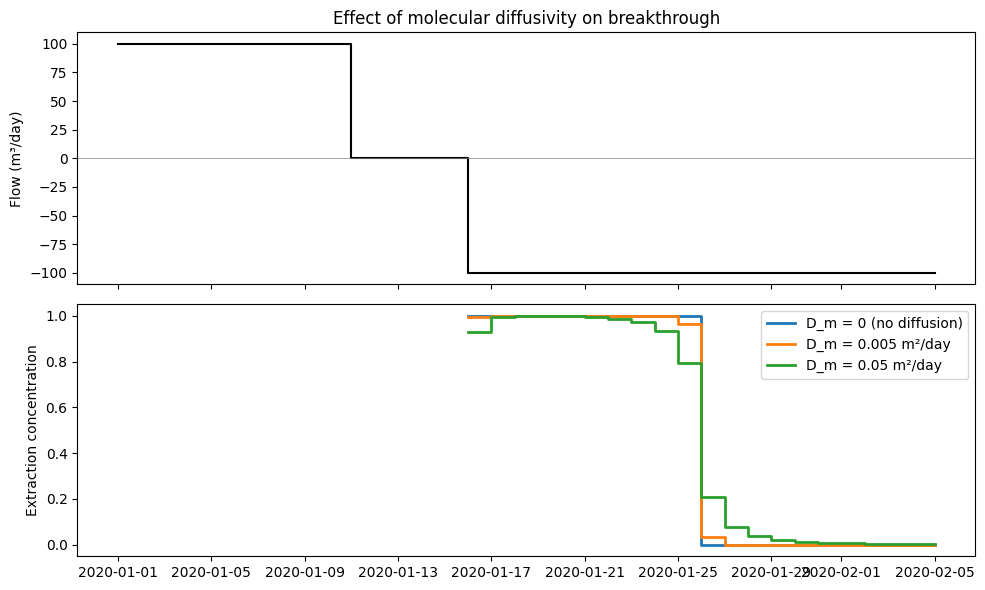

In [4]:
layer_heights = np.array([2.0, 4.0, 6.0, 8.0, 10.0])

cout_no_diff = push_pull_well(
    flow=flow,
    cin=cin,
    tedges=tedges,
    cout_tedges=tedges,
    layer_heights=layer_heights,
    porosity=0.3,
)
cout_low_diff = push_pull_well(
    flow=flow,
    cin=cin,
    tedges=tedges,
    cout_tedges=tedges,
    layer_heights=layer_heights,
    porosity=0.3,
    molecular_diffusivity=0.005,
)
cout_high_diff = push_pull_well(
    flow=flow,
    cin=cin,
    tedges=tedges,
    cout_tedges=tedges,
    layer_heights=layer_heights,
    porosity=0.3,
    molecular_diffusivity=0.05,
)

fig, (ax_flow, ax) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Flow subplot (positive = injection)
xf, yf = step_plot_coords(edges=tedges, values=flow)
ax_flow.plot(xf, yf, color="black", linewidth=1.5)
ax_flow.axhline(0, color="gray", linewidth=0.5)
ax_flow.set_ylabel("Flow (m³/day)")
ax_flow.set_title("Effect of molecular diffusivity on breakthrough")

# Concentration subplot
for cout, label in [
    (cout_no_diff, "D_m = 0 (no diffusion)"),
    (cout_low_diff, "D_m = 0.005 m²/day"),
    (cout_high_diff, "D_m = 0.05 m²/day"),
]:
    x, y = step_plot_coords(edges=tedges, values=cout)
    ax.plot(x, y, label=label, linewidth=2)
ax.set_ylabel("Extraction concentration")
ax.legend()
plt.tight_layout()
plt.show()

## Effect of Layer Heterogeneity

With diffusion, layer heterogeneity becomes visible. Layers with smaller height
push the front further radially, causing more irreversible spreading.

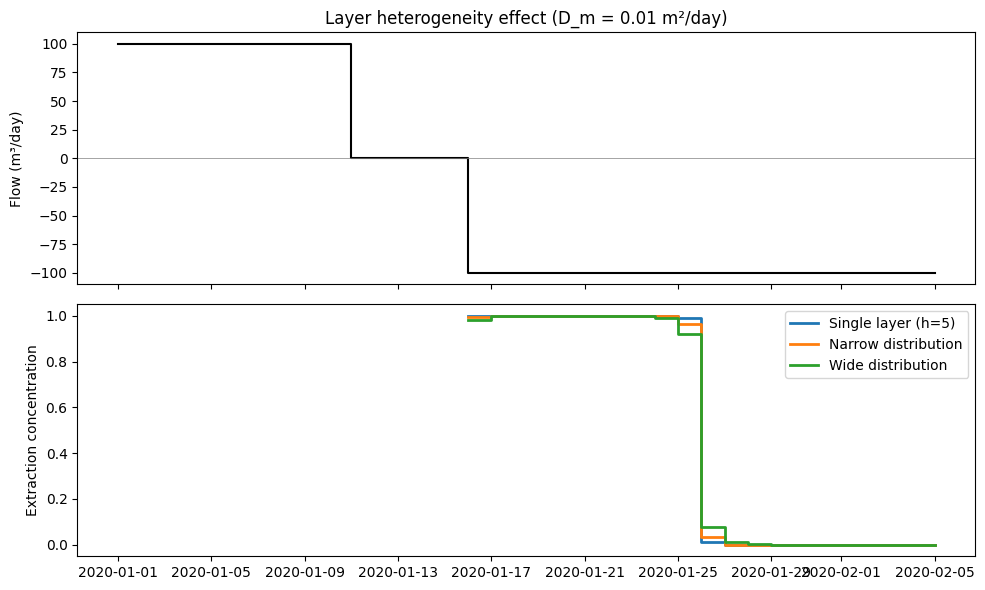

In [5]:
Dm = 0.01

# Single layer (homogeneous)
cout_single = push_pull_well(
    flow=flow,
    cin=cin,
    tedges=tedges,
    cout_tedges=tedges,
    layer_heights=np.array([5.0]),
    porosity=0.3,
    molecular_diffusivity=Dm,
)

# Narrow distribution
cout_narrow = push_pull_well(
    flow=flow,
    cin=cin,
    tedges=tedges,
    cout_tedges=tedges,
    layer_heights=np.array([4.0, 5.0, 6.0]),
    porosity=0.3,
    molecular_diffusivity=Dm,
)

# Wide distribution
cout_wide = push_pull_well(
    flow=flow,
    cin=cin,
    tedges=tedges,
    cout_tedges=tedges,
    layer_heights=np.array([1.0, 3.0, 5.0, 10.0, 20.0]),
    porosity=0.3,
    molecular_diffusivity=Dm,
)

fig, (ax_flow, ax) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Flow subplot (positive = injection)
xf, yf = step_plot_coords(edges=tedges, values=flow)
ax_flow.plot(xf, yf, color="black", linewidth=1.5)
ax_flow.axhline(0, color="gray", linewidth=0.5)
ax_flow.set_ylabel("Flow (m³/day)")
ax_flow.set_title("Layer heterogeneity effect (D_m = 0.01 m²/day)")

# Concentration subplot
for cout, label in [
    (cout_single, "Single layer (h=5)"),
    (cout_narrow, "Narrow distribution"),
    (cout_wide, "Wide distribution"),
]:
    x, y = step_plot_coords(edges=tedges, values=cout)
    ax.plot(x, y, label=label, linewidth=2)
ax.set_ylabel("Extraction concentration")
ax.legend()
plt.tight_layout()
plt.show()

## Gamma-Distributed Layer Heights

The `gamma_push_pull_well` convenience function discretizes a gamma distribution
for layer heights, analogous to the gamma distribution for pore volumes in the
linear transport model.

### Background concentration

With diffusion, the sharp boundary between injected water and ambient aquifer
water gets smeared. The `c_background` parameter specifies the concentration of
the ambient aquifer water beyond the injection zone. For a **tracer test**
(injecting tracer into clean water), `c_background=0` is correct and the
extraction concentration will be slightly below the injection concentration
near the boundary. Setting `c_background` equal to `cin` eliminates any
contrast at the boundary.

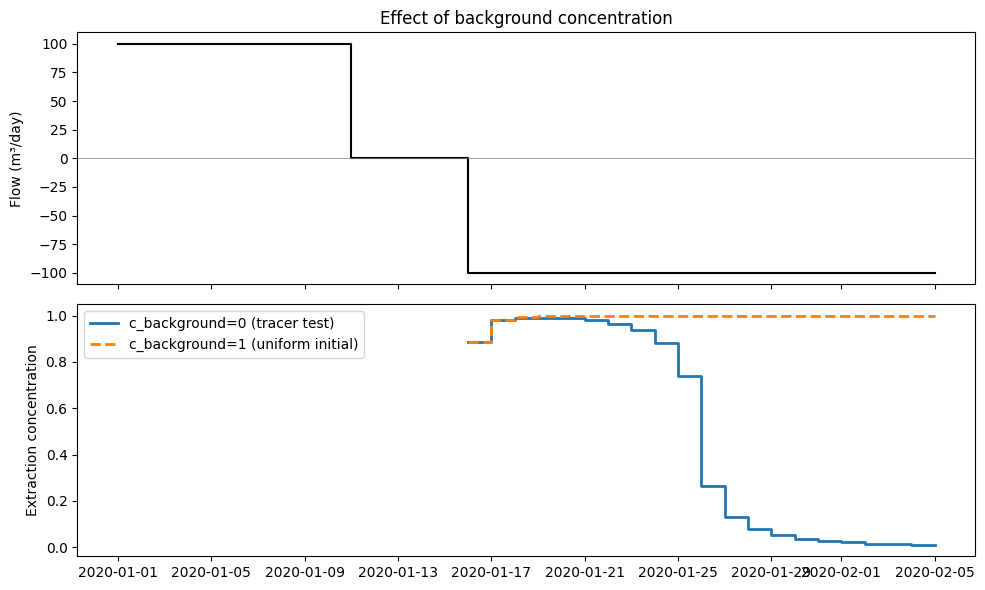

In [6]:
cout_gamma_bg0 = gamma_push_pull_well(
    flow=flow,
    cin=cin,
    tedges=tedges,
    cout_tedges=tedges,
    mean=5.0,
    std=2.0,
    n_bins=50,
    porosity=0.3,
    molecular_diffusivity=0.01,
    c_background=0.0,
)

cout_gamma_bg1 = gamma_push_pull_well(
    flow=flow,
    cin=cin,
    tedges=tedges,
    cout_tedges=tedges,
    mean=5.0,
    std=2.0,
    n_bins=50,
    porosity=0.3,
    molecular_diffusivity=0.01,
    c_background=1.0,
)

fig, (ax_flow, ax) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Flow subplot (positive = injection)
xf, yf = step_plot_coords(edges=tedges, values=flow)
ax_flow.plot(xf, yf, color="black", linewidth=1.5)
ax_flow.axhline(0, color="gray", linewidth=0.5)
ax_flow.set_ylabel("Flow (m³/day)")
ax_flow.set_title("Effect of background concentration")

# Concentration subplot
x, y = step_plot_coords(edges=tedges, values=cout_gamma_bg0)
ax.plot(x, y, label="c_background=0 (tracer test)", linewidth=2)
x, y = step_plot_coords(edges=tedges, values=cout_gamma_bg1)
ax.plot(x, y, label="c_background=1 (uniform initial)", linewidth=2, linestyle="--")
ax.set_ylabel("Extraction concentration")
ax.legend()
plt.tight_layout()
plt.show()